In [ ]:
import pandas as pd # for data manipulation
import seaborn as sns # for statisical data visualization
import matplotlib.pyplot as plt # for creating static, interactive, and animated visualizations

# Load the data
loan_data = pd.read_csv('data/Loan_Default.csv')
# Look at some of it (this is called data exploration)
# loan_data.head()
loan_data.head()


### Exploring the data

Use the `.shape` attribute to display the number of rows and columns in the `loan_data` DataFrame. The output `(154139, 34)` means there are 154,139 entries (rows) and 34 features (columns).


In [ ]:
loan_data.shape
loan_data.columns

The `.info()` method provides a concise summary of the DataFrame, including the index dtype and column dtypes, non-null values, and memory usage. This output confirms the number of non-null entries for each column, highlighting which columns have missing values (e.g., `rate_of_interest`, `property_value`, `income`, `dtir1`), and their data types.


In [ ]:
loan_data.info()

#### Exploring numeric features

Compute descriptive statistics for all numerical columns in the `loan_data` DataFrame using the `.describe()` method.

It provides insights into the **_central tendency, dispersion, and shape of the distribution_** of each column
**_count, mean, std, min, 25%, 50%, 75%, max_**.

The output highlights potential outliers in `LTV` (max 7831.25) and `income` (max 578580.0), and confirms that 'year' has only one unique value (2019).


In [ ]:
loan_data.describe()

- There are outliers in (Incom, LTV) Features
- Year has only one value (2019), Hence we have to drop it
- Drop key columns such as ID


In [ ]:
"""
Drop: 
1- The 'ID' column (which is just an identifier and not useful for analysis) 
2- The 'year' column (as it contains only a single unique value, '2019', offering no variance for analysis)
The `inplace=True` argument modifies the DataFrame directly
# """
# loan_data = pd.read_csv('data/Loan_Default.csv')
# loan_data.drop(['ID', 'year'],axis=1, inplace=True)
# explore it again after we've dropped the columns we don't want
# loan_data.shape
# loan_data.describe()
loan_data.info()

In [ ]:
# Dropping rows for educational purposes
total_rows = len(loan_data)
loan_data.drop(range(total_rows - 100, total_rows), axis=0, inplace=True)
loan_data.info()

#### Exploring Categorical features

Generate descriptive statistics for all categorical (object type) columns in the `loan_data` DataFrame using `describe(include = 'object')`.

It shows the count of non-null values, number of unique categories, the most frequent category (`top`), and its frequency (`freq`) for each categorical feature.

_This helps in understanding the distribution and common values within these columns._


In [ ]:
loan_data.describe(include = 'object') # type: ignore

> _Tip_
> Note above that 21 columns here means 21 categorical variables

Check the distribution of values within the 'age' column using `value_counts()`. \
It reveals the frequency of each age group, showing that the '45-54' age group is the most common.


In [ ]:
loan_data['age'].value_counts()

Calculate the proportional distribution of different genders in the 'Gender' column using `value_counts(normalize = True)`. It shows that 'Male' is the most prevalent gender category, followed by 'Joint', 'Sex Not Available', and 'Female'.


In [ ]:
loan_data['Gender'].value_counts(normalize = True)

#### Check for duplicates


In [ ]:
loan_data = pd.read_csv('data/Loan_Default.csv')
columns= ['loan_limit', 'Gender', 'approv_in_adv','loan_purpose', 'Credit_Worthiness', 'open_credit',
          'business_or_commercial','Interest_rate_spread', 'Upfront_charges', 'Neg_ammortization',
          'interest_only', 'lump_sum_payment','construction_type', 'occupancy_type', 'Secured_by', 'total_units',
          'credit_type', 'co-applicant_credit_type','submission_of_application', 'LTV', 'Region', 'Security_Type', 'ID', 'year']
loan_data.drop(columns, axis=1, inplace =True)
# The code in this cell drops a whopping 23 columns off the dataframe which makes our 
loan_data.shape

Check for duplicate rows in the `loan_data` DataFrame using `duplicated().sum()`. The output `6` indicates that there are 6 exact duplicate rows present in the dataset.


In [ ]:
loan_data.duplicated().sum()

Remove the identified duplicate rows from the `loan_data` DataFrame using `drop_duplicates(inplace=True)`. The `inplace=True` argument modifies the DataFrame directly.


In [ ]:
loan_data.drop_duplicates(inplace=True)

In [ ]:
# loan_data.duplicated().sum()
loan_data.reset_index(inplace=True)
loan_data.info()

#### Missing values per feature


Calculate the number of missing values for each column in the `loan_data` DataFrame using `isna().sum()`. This provides a clear picture of which features still have null values and how many, indicating where imputation or further handling of missing data might be required.


In [ ]:
loan_data.isna().sum()

Generate a pair plot of the numerical features in the `loan_data` DataFrame using `sns.pairplot()`. A pair plot creates a grid of scatter plots for all pairs of numerical variables and histograms/KDE plots for single variables. This helps visualize relationships between variables and understand their individual distributions. The output `<seaborn.axisgrid.PairGrid object>` refers to the generated plot object.


#### Feature analysis


In [ ]:
sns.pairplot(loan_data)

Generate a count plot for the 'loan_type' column using `sns.countplot()`. A count plot shows the counts of observations in each category of a categorical variable. This visualization helps understand the distribution of different loan types in the dataset.


In [ ]:
sns.countplot(data=loan_data, x='loan_type')
plt.show()

Create two count plots side-by-side to visualize the distribution of 'loan_type' and 'age' categories, further segmented by the 'Status' (loan default status). This helps in understanding how these categorical features relate to the 'Status' of the loan, potentially revealing patterns or differences in default rates across categories.


In [ ]:
categorical_feats = loan_data[[ 'loan_type', 'age']]
fig , ax = plt.subplots(1,2,figsize = (8,4))     # set up 2 x 2 frame count plot with figsize 10 x 10
for i , subplots in zip (categorical_feats, ax.flatten()):
    sns.countplot(categorical_feats[i],hue = loan_data['Status'],ax = subplots, palette = 'BuPu')
plt.show()

Calculate the correlation matrix for the numerical features in `loan_data` and visualizes it as a heatmap using `sns.heatmap(corr, annot=True)`. The `annot=True` argument displays the correlation coefficients on the heatmap cells. This visualization helps identify strong positive or negative linear relationships between features, which can be useful for feature selection or understanding multicollinearity.


### Features correlation


In [ ]:
corr = loan_data.corr()
sns.heatmap(corr, annot=True)
plt.show()

- Features (income, dtir1) are highly correlated
- Features (rate_of_interest, loan_amount) are highly correlated
- Features (property_value, loan_amount) are highly correlated


## Student Exercise

## Analysing Insurance Dataset


In [31]:
insur_data = pd.read_csv('data/Insurance.csv')
insur_data.drop(['id'], axis=1, inplace=True)
# insur_data.columns
# insur_data.shape
# Insurance_data.info()
insur_data.describe()


,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,382154.000000,382154.000000,382154.000000,382154.000000,382154.000000,382154.000000,382154.000000,382154.000000
mean,38.545691,0.998108,26.406867,0.489182,30711.271362,111.939812,154.189429,0.163811
std,15.226897,0.043455,13.181241,0.499884,17061.595532,54.286511,83.735107,0.370104
min,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,25.000000,1.000000,15.000000,0.000000,24546.000000,26.000000,81.000000,0.000000
50%,36.000000,1.000000,28.000000,0.000000,31692.000000,145.000000,154.000000,0.000000
75%,49.000000,1.000000,35.000000,1.000000,39447.750000,152.000000,227.000000,0.000000
max,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


#### Exploring Categorical features


In [35]:
insur_data.describe(include = 'object')
insur_data['Vehicle_Age'] #.value_counts()
insur_data.head()
# Insurance_data['Gender'].value_counts(normalize = True)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,Male,22,1,7.0,1,< 1 Year,No,2630.0,152.0,16,0
1,Male,42,1,28.0,0,1-2 Year,Yes,43327.0,26.0,135,0
2,Female,66,1,33.0,0,1-2 Year,Yes,35841.0,124.0,253,0
3,Female,22,1,33.0,0,< 1 Year,No,27645.0,152.0,69,0
4,Male,28,1,46.0,1,< 1 Year,No,29023.0,152.0,211,0


In [37]:
# Check for duplicates
insur_data.duplicated().sum()

np.int64(286)

In [38]:
insur_data.drop_duplicates(inplace=True)
insur_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381868 entries, 0 to 382153
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Gender                381868 non-null  object 
 1   Age                   381868 non-null  int64  
 2   Driving_License       381868 non-null  int64  
 3   Region_Code           381868 non-null  float64
 4   Previously_Insured    381868 non-null  int64  
 5   Vehicle_Age           381868 non-null  object 
 6   Vehicle_Damage        381868 non-null  object 
 7   Annual_Premium        381868 non-null  float64
 8   Policy_Sales_Channel  381868 non-null  float64
 9   Vintage               381868 non-null  int64  
 10  Response              381868 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 35.0+ MB


In [40]:
insur_data.duplicated().sum()

np.int64(0)

In [41]:
# Missing values per feature

Insurance_data.isna().sum()

Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

#### Feature analysis


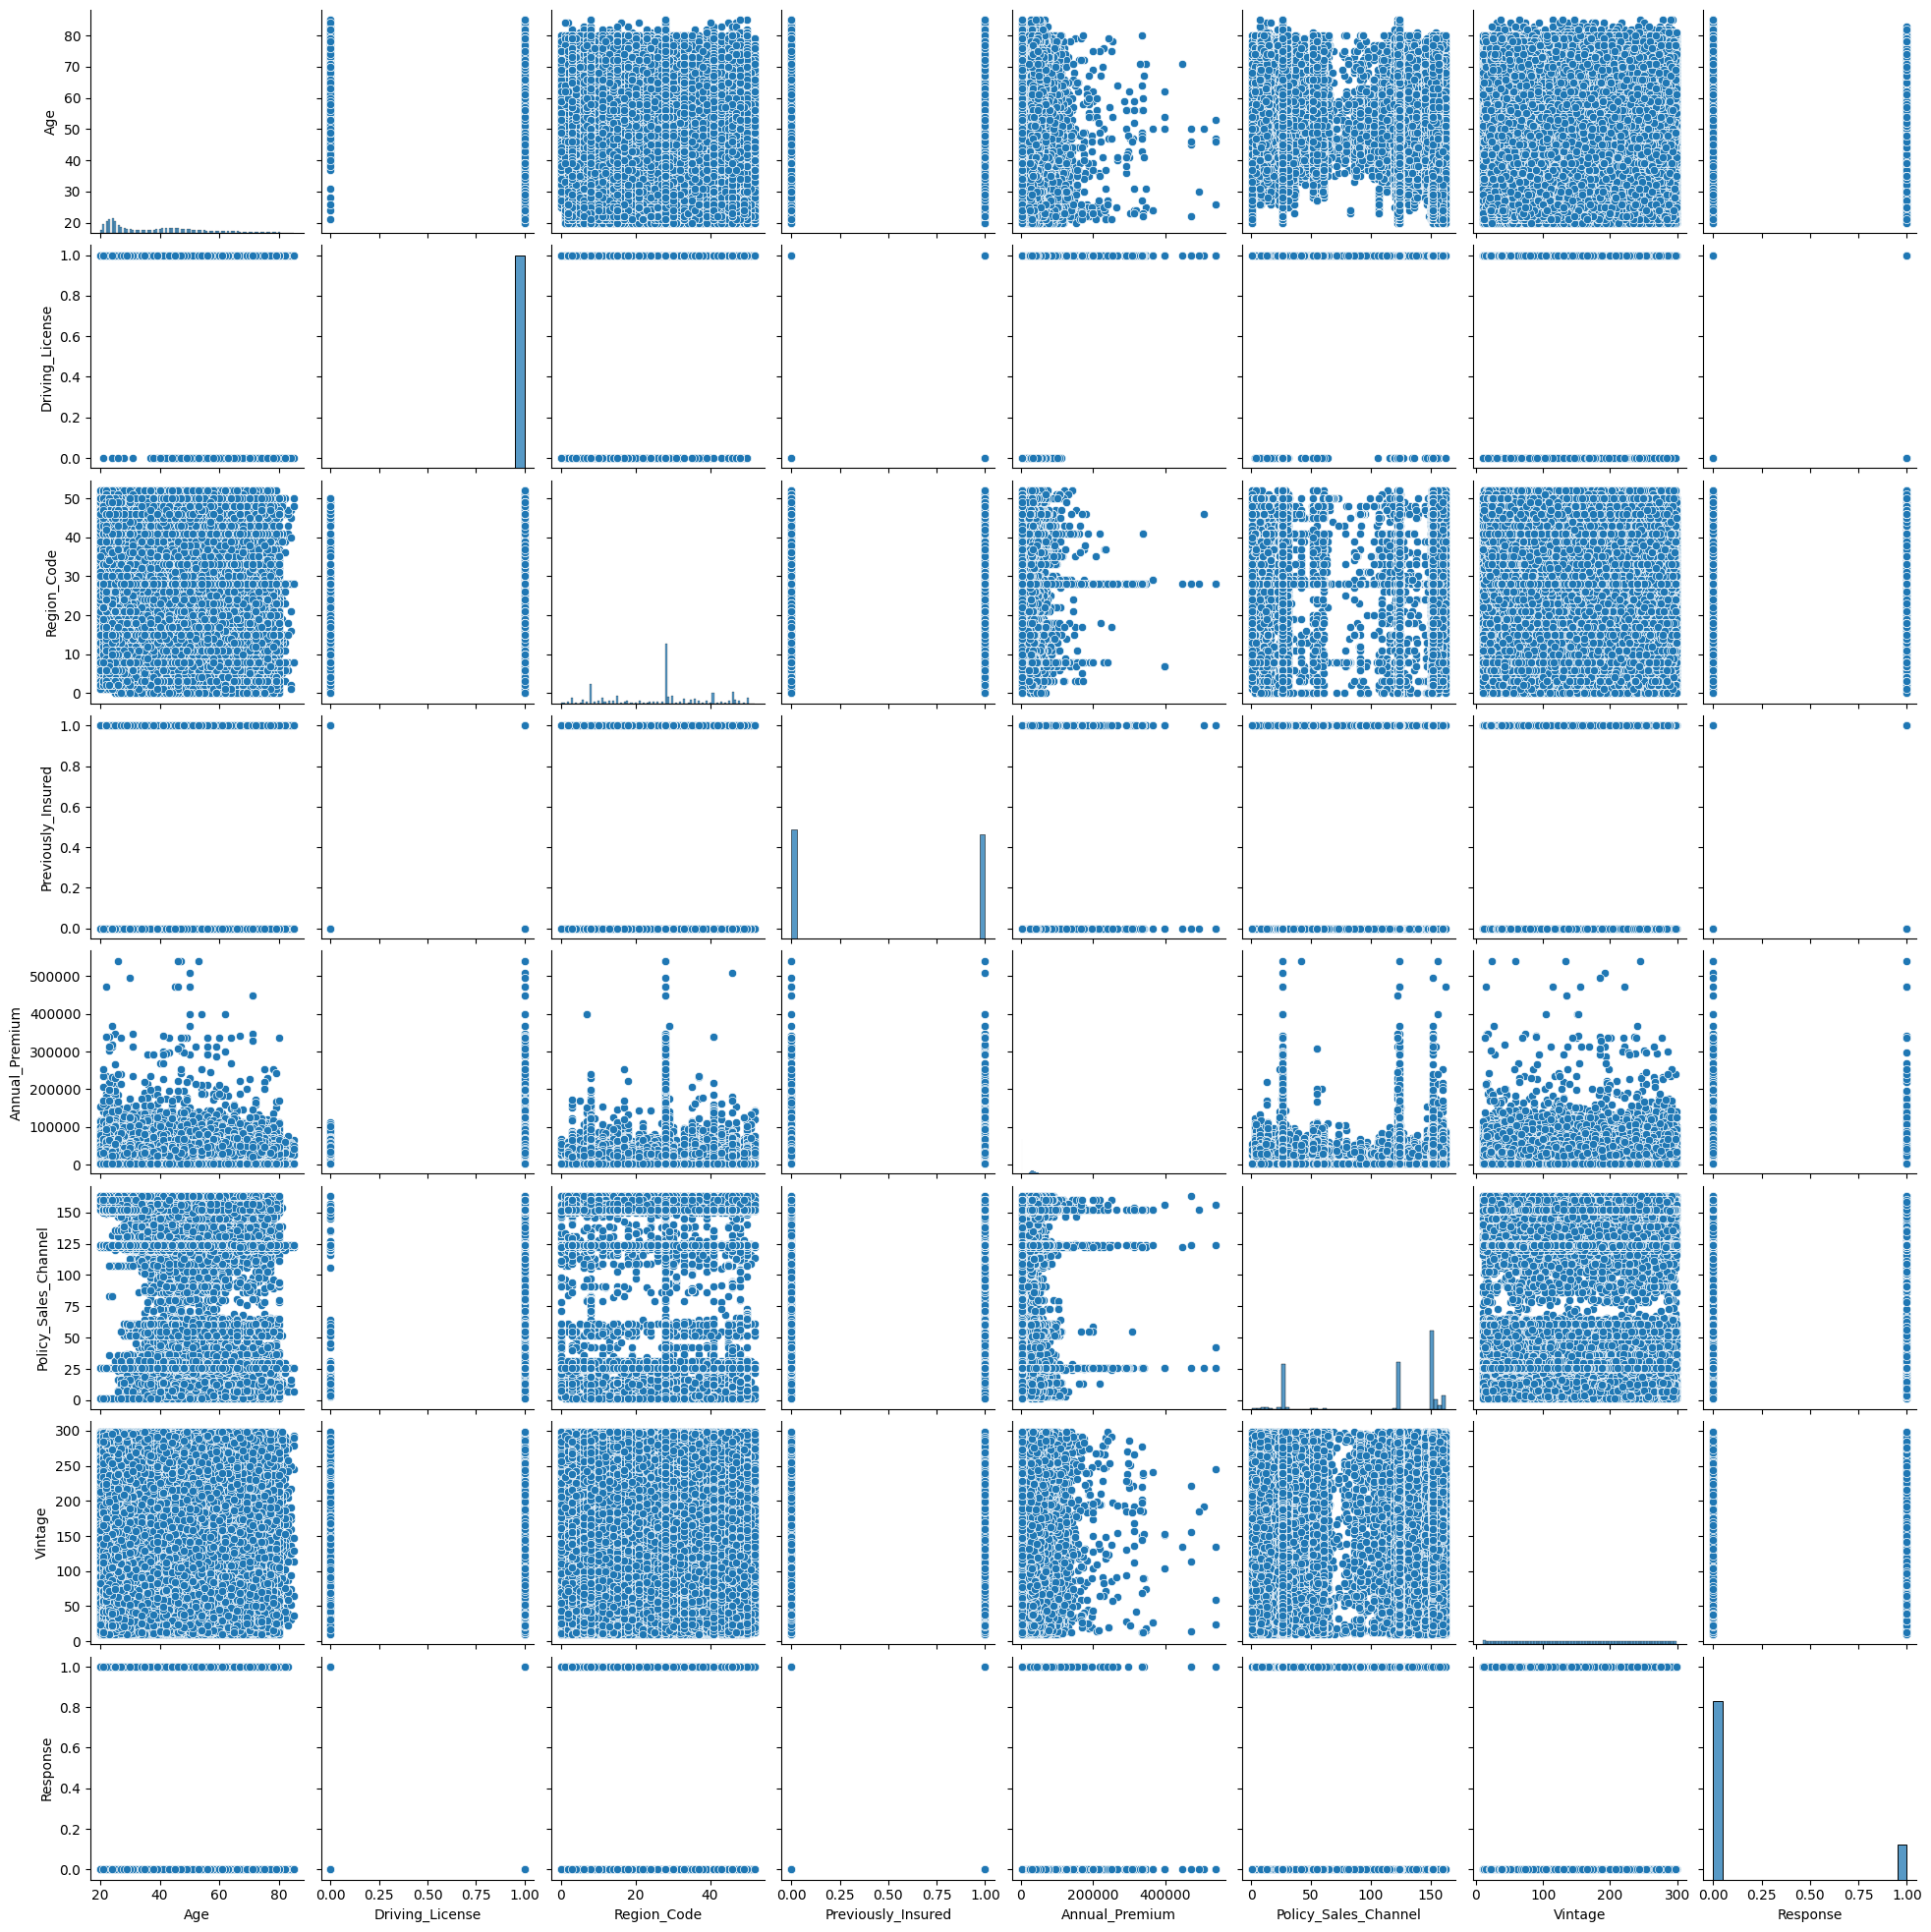

In [42]:
sns.pairplot(insur_data)

In [43]:
categorical_feats=[i for i in insur_data.columns if insur_data.dtypes[i]=='object']
categorical_feats

['Gender', 'Vehicle_Age', 'Vehicle_Damage']

In [ ]:
categorical_feats_data = insur_data[categorical_feats]

/tmp/ipykernel_36136/934598230.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=categorical_feats_data, x=i, ax=subplots, palette='BuPu')
/tmp/ipykernel_36136/934598230.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=categorical_feats_data, x=i, ax=subplots, palette='BuPu')
/tmp/ipykernel_36136/934598230.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=categorical_feats_data, x=i, ax=subplots, palette='BuPu')


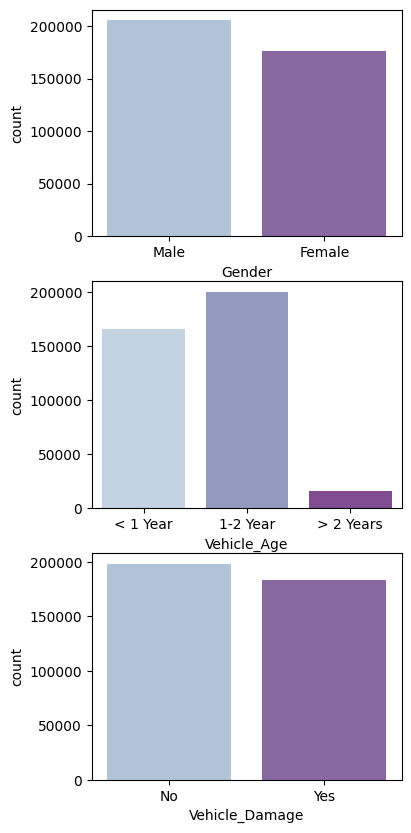

In [46]:
fig , ax = plt.subplots(3,1,figsize = (4, 10))     # set up 2 x 2 frame count plot with figsize 10 x 10
for i , subplots in zip (categorical_feats_data.columns, ax.flatten()):
    sns.countplot(data=categorical_feats_data, x=i, ax=subplots, palette='BuPu')
plt.show()

### Features correlation


In [47]:
only_numerical_feats = insur_data
corr = insur_data.corr()
sns.heatmap(corr, annot=True)
plt.show()

# Features (Response, Previously_Insured) are highly correlated
# Features (Age, Policy_Sales_Channel) are highly correlated


ValueError: could not convert string to float: 'Male'